# 03 — Full-Dataset Exploratory Data Analysis

## Research role

This notebook examines the 19,948 trajectory-level passenger-car records created by the multi-recording feature pipeline. Its purpose is to identify data imbalance, skewness, extreme values, redundancy, and city effects before preprocessing and model training.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

FEATURE_PATH = PROJECT_ROOT / "data" / "processed" / "sind_full_core_behavior_features.csv"
data = pd.read_csv(FEATURE_PATH)
CORE_FEATURES = [
    "mean_speed_mps", "max_speed_mps", "speed_std_mps",
    "mean_long_acc_mps2", "max_acceleration_mps2",
    "max_deceleration_mps2", "acceleration_std_mps2",
    "mean_abs_jerk_mps3", "observed_stop_transition_count",
    "stopped_time_ratio",
]
assert data["trajectory_uid"].is_unique
assert data[CORE_FEATURES].isna().sum().sum() == 0
assert np.isinf(data[CORE_FEATURES].to_numpy()).sum() == 0
assert data["recording_id"].nunique() == 56
print(f"Trajectories: {len(data):,}")
print(f"Cities: {data['city'].nunique()}")
print(f"Recordings: {data['recording_id'].nunique()}")

Trajectories: 19,948
Cities: 4
Recordings: 56


## 1. Dataset composition

A pooled clustering model can be influenced by cities or recordings that contribute more trajectories. This section quantifies that imbalance.

In [2]:
city_counts = data["city"].value_counts().rename_axis("city").reset_index(name="trajectory_count")
city_counts["percentage"] = city_counts["trajectory_count"] / len(data) * 100
city_counts

,city,trajectory_count,percentage
0,Changchun,8665,43.437939
1,Xi'an,4822,24.172849
2,Tianjin,4533,22.724083
3,Chongqing,1928,9.665129


In [3]:
recording_counts = data.groupby(["city", "recording_id"]).size().reset_index(name="trajectory_count").sort_values("trajectory_count", ascending=False)
recording_counts.head(15)

,city,recording_id,trajectory_count
5,Changchun,changchun_pudong_523_007,1354
6,Changchun,changchun_pudong_523_008,1254
1,Changchun,changchun_pudong_507_010,1207
0,Changchun,changchun_pudong_507_009,1166
3,Changchun,changchun_pudong_523_005,1084
2,Changchun,changchun_pudong_507_011,1082
4,Changchun,changchun_pudong_523_006,912
7,Changchun,changchun_pudong_xx,606
42,Xi'an,xian_412_m2,600
43,Xi'an,xian_412_m3,505


### Interpretation

The city and recording counts are unequal. This is expected for real traffic data, but pooled model metrics alone are insufficient. Later experiments must include recording-level and city-level validation.

## 2. Descriptive statistics and skewness

Percentiles provide more information than the maximum alone. A very large maximum with a much smaller 99th percentile may indicate a rare event or possible artifact.

In [4]:
descriptive_statistics = data[CORE_FEATURES].describe(percentiles=[0.01,0.05,0.25,0.50,0.75,0.95,0.99]).T
descriptive_statistics["skewness"] = data[CORE_FEATURES].skew()
descriptive_statistics["zero_percentage"] = data[CORE_FEATURES].eq(0).mean() * 100
descriptive_statistics

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,skewness,zero_percentage
mean_speed_mps,19948.0,5.353730,3.153753,0.022036,0.498704,1.341120,2.498985,5.216623,7.394982,11.061558,13.974868,22.372928,0.648226,0.000000
max_speed_mps,19948.0,10.084620,2.657055,0.898105,4.626830,6.073200,8.322617,9.965982,11.714091,14.411756,16.606901,99.466762,2.303992,0.000000
speed_std_mps,19948.0,2.100883,1.066481,0.048426,0.282448,0.534653,1.210415,2.039976,2.896450,3.928030,4.523418,6.263775,0.285231,0.000000
mean_long_acc_mps2,19948.0,0.157115,0.288473,-1.718072,-0.564373,-0.301776,0.014410,0.123991,0.299579,0.667058,0.975424,2.308666,0.296151,0.000000
max_acceleration_mps2,19948.0,1.960201,1.883700,0.000000,0.166486,0.500995,1.078464,1.555751,2.145588,5.357812,9.346379,126.185481,16.509502,0.290756
max_deceleration_mps2,19948.0,1.533011,1.477465,-0.000000,0.000000,0.188368,0.830092,1.426473,2.056066,3.109854,4.255755,115.736161,35.588569,2.200722
acceleration_std_mps2,19948.0,0.733408,0.376128,0.055932,0.160523,0.276937,0.495271,0.666785,0.882943,1.419931,2.110375,8.071731,2.213727,0.000000
mean_abs_jerk_mps3,19948.0,0.555202,0.316502,0.008006,0.167220,0.223827,0.343742,0.479493,0.673523,1.160135,1.655197,6.552034,2.546933,0.000000
observed_stop_transition_count,19948.0,0.493934,0.826392,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2.000000,4.000000,15.000000,3.660530,61.785643
stopped_time_ratio,19948.0,0.208046,0.285888,0.000000,0.000000,0.000000,0.000000,0.000000,0.501026,0.718722,0.831031,0.995190,0.875436,59.374373


## 3. IQR outlier audit

The IQR rule is used only as a diagnostic. A statistical outlier is not automatically a data error.

In [5]:
outlier_rows = []
for feature in CORE_FEATURES:
    q1 = data[feature].quantile(0.25)
    q3 = data[feature].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    mask = (data[feature] < lower) | (data[feature] > upper)
    outlier_rows.append({"feature": feature, "lower_bound": lower, "upper_bound": upper, "outlier_count": int(mask.sum()), "outlier_percentage": mask.mean()*100})
outlier_audit = pd.DataFrame(outlier_rows)
outlier_audit.sort_values("outlier_percentage", ascending=False)

,feature,lower_bound,upper_bound,outlier_count,outlier_percentage
4,max_acceleration_mps2,-0.522222,3.746275,1669,8.366754
3,mean_long_acc_mps2,-0.413343,0.727331,1289,6.461801
7,mean_abs_jerk_mps3,-0.150930,1.168195,980,4.912773
6,acceleration_std_mps2,-0.086238,1.464452,889,4.456587
8,observed_stop_transition_count,-1.500000,2.500000,449,2.250852
5,max_deceleration_mps2,-1.008868,3.895026,290,1.453780
1,max_speed_mps,3.235405,16.801302,231,1.158011
0,mean_speed_mps,-4.845009,14.738976,111,0.556447
2,speed_std_mps,-1.318637,5.425502,7,0.035091
9,stopped_time_ratio,-0.751540,1.252566,0,0.000000


## 4. City-level comparison and correlation

Medians reduce the influence of extreme values. Spearman correlation is rank-based and suitable for skewed variables.

In [6]:
city_feature_medians = data.groupby("city")[CORE_FEATURES].median().T
city_feature_medians

city,Changchun,Chongqing,Tianjin,Xi'an
mean_speed_mps,5.205030,4.311905,5.204662,5.726798
max_speed_mps,10.719491,8.611887,8.191538,10.986923
speed_std_mps,2.523596,1.895078,1.334991,1.899360
mean_long_acc_mps2,0.137616,0.098033,0.152750,0.093781
max_acceleration_mps2,1.801525,1.387054,1.263154,1.402713
max_deceleration_mps2,1.692687,1.313150,0.939332,1.479476
acceleration_std_mps2,0.752999,0.595126,0.580595,0.613188
mean_abs_jerk_mps3,0.514010,0.354641,0.419590,0.522937
observed_stop_transition_count,0.000000,0.000000,0.000000,0.000000
stopped_time_ratio,0.000000,0.000000,0.000000,0.000000


In [7]:
spearman_correlation = data[CORE_FEATURES].corr(method="spearman")
spearman_correlation

,mean_speed_mps,max_speed_mps,speed_std_mps,mean_long_acc_mps2,max_acceleration_mps2,max_deceleration_mps2,acceleration_std_mps2,mean_abs_jerk_mps3,observed_stop_transition_count,stopped_time_ratio
mean_speed_mps,1.000000,0.374578,-0.507909,0.206281,-0.282828,-0.267812,0.062458,0.351687,-0.795669,-0.852110
max_speed_mps,0.374578,1.000000,0.394164,0.125987,0.177655,0.206467,0.300291,0.114310,-0.024300,-0.012703
speed_std_mps,-0.507909,0.394164,1.000000,0.116891,0.509117,0.417887,0.365624,-0.068719,0.596112,0.603342
mean_long_acc_mps2,0.206281,0.125987,0.116891,1.000000,0.365636,-0.357761,0.064935,0.202402,-0.226887,-0.209049
max_acceleration_mps2,-0.282828,0.177655,0.509117,0.365636,1.000000,0.372119,0.648406,0.415832,0.315446,0.331721
max_deceleration_mps2,-0.267812,0.206467,0.417887,-0.357761,0.372119,1.000000,0.668091,0.344684,0.358905,0.333163
acceleration_std_mps2,0.062458,0.300291,0.365624,0.064935,0.648406,0.668091,1.000000,0.650859,0.025928,-0.029085
mean_abs_jerk_mps3,0.351687,0.114310,-0.068719,0.202402,0.415832,0.344684,0.650859,1.000000,-0.317494,-0.413223
observed_stop_transition_count,-0.795669,-0.024300,0.596112,-0.226887,0.315446,0.358905,0.025928,-0.317494,1.000000,0.905939
stopped_time_ratio,-0.852110,-0.012703,0.603342,-0.209049,0.331721,0.333163,-0.029085,-0.413223,0.905939,1.000000


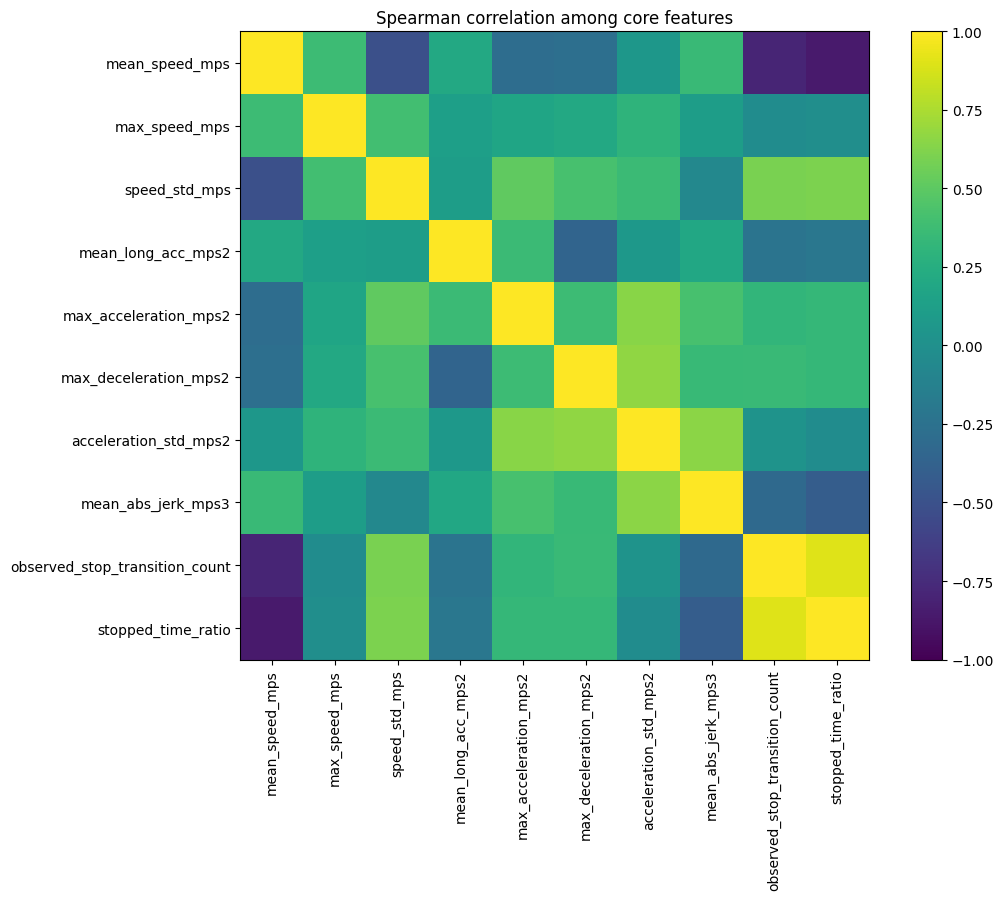

In [8]:
fig, ax = plt.subplots(figsize=(11, 9))
image = ax.imshow(spearman_correlation.to_numpy(), vmin=-1, vmax=1)
ax.set_xticks(range(len(CORE_FEATURES)))
ax.set_yticks(range(len(CORE_FEATURES)))
ax.set_xticklabels(CORE_FEATURES, rotation=90)
ax.set_yticklabels(CORE_FEATURES)
fig.colorbar(image, ax=ax)
ax.set_title("Spearman correlation among core features")
plt.tight_layout()
plt.show()

## 5. Provisional preprocessing candidates

The next stage compares three pipelines: winsorization plus StandardScaler; no winsorization plus RobustScaler; and winsorization plus RobustScaler. Stop-transition count and stopped-time ratio are preserved by default.

In [9]:
decision_table = pd.read_csv(PROJECT_ROOT / "outputs" / "tables" / "preprocessing_decision_table.csv")
decision_table

,feature,feature_type,min,p01,median,p99,max,skewness,iqr_outlier_percentage,provisional_outlier_treatment,provisional_scaling_plan,research_note
0,mean_speed_mps,continuous,0.022036,0.498704,5.216623,13.974868,22.372928,0.648226,0.556447,Compare 1st-99th percentile winsorization agai...,Compare StandardScaler and RobustScaler,Continuous distance-sensitive input; assess ta...
1,max_speed_mps,continuous,0.898105,4.626830,9.965982,16.606901,99.466762,2.303992,1.158011,Compare 1st-99th percentile winsorization agai...,Compare StandardScaler and RobustScaler,Strong right tail and very large maxima; raw t...
2,speed_std_mps,continuous,0.048426,0.282448,2.039976,4.523418,6.263775,0.285231,0.035091,Compare 1st-99th percentile winsorization agai...,Compare StandardScaler and RobustScaler,Continuous distance-sensitive input; assess ta...
3,mean_long_acc_mps2,continuous,-1.718072,-0.564373,0.123991,0.975424,2.308666,0.296151,6.461801,Compare 1st-99th percentile winsorization agai...,Compare StandardScaler and RobustScaler,Continuous distance-sensitive input; assess ta...
4,max_acceleration_mps2,continuous,0.000000,0.166486,1.555751,9.346379,126.185481,16.509502,8.366754,Compare 1st-99th percentile winsorization agai...,Compare StandardScaler and RobustScaler,Strong right tail and very large maxima; raw t...
5,max_deceleration_mps2,continuous,-0.000000,0.000000,1.426473,4.255755,115.736161,35.588569,1.453780,Compare 1st-99th percentile winsorization agai...,Compare StandardScaler and RobustScaler,Strong right tail and very large maxima; raw t...
6,acceleration_std_mps2,continuous,0.055932,0.160523,0.666785,2.110375,8.071731,2.213727,4.456587,Compare 1st-99th percentile winsorization agai...,Compare StandardScaler and RobustScaler,Continuous distance-sensitive input; assess ta...
7,mean_abs_jerk_mps3,continuous,0.008006,0.167220,0.479493,1.655197,6.552034,2.546933,4.912773,Compare 1st-99th percentile winsorization agai...,Compare StandardScaler and RobustScaler,Continuous distance-sensitive input; assess ta...
8,observed_stop_transition_count,discrete_count,0.000000,0.000000,0.000000,4.000000,15.000000,3.660530,2.250852,Preserve as a valid discrete count; inspect se...,Scale jointly after treatment decision,Do not winsorize by default because repeated s...
9,stopped_time_ratio,bounded_ratio,0.000000,0.000000,0.000000,0.831031,0.995190,0.875436,0.000000,Preserve because naturally bounded between 0 a...,Scale jointly after treatment decision,Do not winsorize by default


## Notebook conclusion

- Final EDA population: **19,948 trajectories**
- Cities: **4**
- Recordings: **56**
- Missing core feature values: **0**
- Duplicate trajectory IDs: **0**

The dataset is structurally ready, but distance-sensitive preprocessing must be compared before PCA and clustering.